In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [16]:
hbar = 1973 #eV angstrom
m_e = .511*10**6 # eV/c^2
epsilon_0 = 1/(4*np.pi)
e =3.795 # (eV angstrom)^1/2
A = -hbar**2/(2*m_e)
# Bohr radius
a0 = 4 * np.pi * epsilon_0 * hbar**2 / (m_e * e**2)

In [17]:
# Constructing Hamiltonian matrix
def hamiltonian_matrix(n, dr, potential_values):
    
    """ To construct the hamiltonian matrix we need:
        n : (int) number of interior grid points
        dx : (float) grid spacing
        potential_values : (array like) potential energy value at every grid point
    """
    
    """ Kinetic Matrix """
    kinetic_matrix = np.zeros((n, n))
    for i in range(n):
        kinetic_matrix[i,i] = -2 
        if i+1 < n:
            kinetic_matrix[i+1,i]= kinetic_matrix[i,i+1] = 1 
    kinetic_energy = A*kinetic_matrix/dr**2
    
    """ Potential Energy Matrix """
    potential_energy = np.diag(potential_values)
    
    hamiltonian = kinetic_energy + potential_energy
    
    return hamiltonian

In [18]:
def hydrogen_potential(r, l):
    # Coulomb potential
    coulomb = -e**2 / (4 * np.pi * epsilon_0 * r)
    # Centrifugal potential
    centrifugal = hbar**2 * l * (l + 1) / (2 * m_e * r**2)
    return coulomb + centrifugal

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

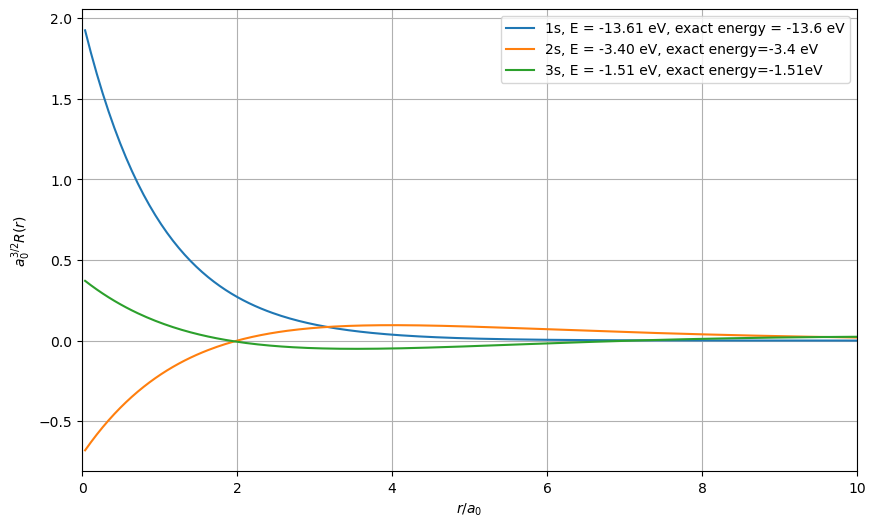

In [42]:
def solve_and_plot(r_max,l,interior_points, state_number):
    if interior_points <= 0:
        raise ValueError("interior_points must be positive.")

    if state_number < 0 or state_number >= interior_points:
        raise ValueError("Invalid state_number.")
    
    dr = r_max/(interior_points+1)

    r = np.linspace(dr, r_max-dr, interior_points)
    potential = hydrogen_potential(r, l)
    
    hamiltonian = hamiltonian_matrix(interior_points, dr, potential)
    
    energies, wavevector = np.linalg.eigh(hamiltonian)
    #analytical energies
    exact_energy = -13.6/(state_number+1)**2
    # Plotting the normalized wavefunctions
    plt.figure(figsize=(10,6))
    u = wavevector[:, state_number]
    if u[np.argmax(np.abs(u))] < 0:
        u = -u
    norm = np.sum(np.abs(u)**2)*dr
    u_norm = u / np.sqrt(norm)
    
    #calculating R
    R = u_norm/r
    return r/a0, R*a0**1.5, energies[state_number], exact_energy
r = 20
x, y, energy, EE=solve_and_plot(r,0,1000,0)
x1, y1, energy1, EE1= solve_and_plot(r,0,1000,1)
x2, y2, energy2, EE2 = solve_and_plot(r,0,1000,2)
plt.plot(x, y, label=f"1s, E = {energy:.2f} eV, exact energy = {EE} eV")
plt.plot(x1, y1, label=f"2s, E = {energy1:.2f} eV, exact energy={EE1} eV")
plt.plot(x2,y2, label=f"3s, E = {energy2:.2f} eV, exact energy={EE2:.2f}eV")
plt.xlabel(r"$r/a_0$")
plt.ylabel(r"$a_0^{3/2}R(r)$")
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.show()


